# ATLAS VZ Signal Search - Project 4 (Thomas Griffiths)

This project is aimed at implementing a full particle physics analysis with a search for heavy Higgs decay to $ZV$ through 1 TeV $ggH_{1000}$ events, specifically looking at $ Z \rightarrow l^+ l^-$ and $V \rightarrow qq'$ which are then taken as high boosted overlapping jets known as fat jets ($J$). The signal is shuffled into three Standard Model background processes: 'diboson', 'Z + jets', and 'top'. The 'diboson' process are non-peaking $qq \rightarrow Z(ll)V(qq')$, 'Z + jets' events follows $qq \rightarrow Z(ll) + \text{jets}$, and 'top' process wtih $t\overline{t}$ decay as $t  \rightarrow W b \rightarrow ll + \text{jets}$. Therefore, our analysis approach follows three stages to improve the correct classification of the signal events:

1. Kinematic Cuts - we visualize the input variables and apply manual cuts to selectively enchance signal-to-background ratio.
2. Hypothesis Testing - fit the reconstructed $ZV$ mass spectrum under $H_1$ (signal + background) and $H_0$ (background only), and extracting the signficiance with Wilk's theorem.
3. Nueral Network Classification - train a binary classifier to suppress background and compare with the inclusion of the reconstructed mass as a training feature.

In [55]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn import model_selection, preprocessing
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score

from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_dist

seed = 64 # Favorite Number

## Load In ATLAS Data
Four CSV files loaded: three SM background processes (Diboson, Z+jets, Top = 6.8M events) and a signal process $\text{ggH}_{1000}$ ($\sim$ 50k events). 
Each event contains a 'Weight' related to the cross-section of that process, meaning the weighted histograms highlight the physical event counts rather than the raw simulation statistics. Can be found at:

https://cernbox.cern.ch/s/WLHOLZEsxUQiSeo

In [56]:
# Column names for the data files
cols = ['EventID', 'Weight', 'MET', 'Topology', 'Zll_mass', 'Zll_pt', 'fatjet_C2', 'fatjet_D2',
        'fatjet_E', 'fatjet_eta', 'fatjet_phi', 'fatjet_pt', 'isSignal', 'lep1_E', 'lep1_charge',
        'lep1_eta', 'lep1_phi', 'lep1_pt', 'lep2_E', 'lep2_charge', 'lep2_eta', 'lep2_phi', 'lep2_pt',
        'reco_zv_mass', 'truth_zv_mass']

# Note: D_2 here is a hardonic discriminant between one large jet (large D_2) and two separated jets (small D_2).
# As will see later, ttbar production events will also produce neutrinos that will lead to large amounts of transverse missing energy.

# Path to the data files
path = "data/W18_Proj4/"

# Use low_memory = false to issues with mixed data types in columns with large files
diboson = pd.read_csv(path + "Diboson.csv", names=cols, low_memory=False, header = 0)
top = pd.read_csv(path + "Top.csv", names=cols, low_memory=False, header = 0)
zjets = pd.read_csv(path + "Zjets.csv", names=cols, low_memory=False, header = 0)
signal = pd.read_csv(path + "ggH1000.csv", names=cols, low_memory=False, header = 0)

# Reset the index of each DataFrame
diboson.reset_index(drop = True, inplace=True)
top.reset_index(drop = True, inplace=True)
zjets.reset_index(drop = True, inplace=True)
signal.reset_index(drop = True, inplace=True)

# Convert all columns to numeric
diboson = diboson[cols].apply(pd.to_numeric, errors='coerce')
top = top[cols].apply(pd.to_numeric, errors='coerce')
zjets = zjets[cols].apply(pd.to_numeric, errors='coerce')
signal = signal[cols].apply(pd.to_numeric, errors='coerce')

# Label process for plotting
diboson['process'] = 'Diboson'
top['process'] = 'Top'
zjets['process'] = 'Z+jets'
signal['process'] = 'Signal (ggH1000)'

# Combine backgrounds into a single DataFrame
backgrounds = pd.concat([diboson, top, zjets], ignore_index=True)

# Verification print
print(f"Background entrier: {len(backgrounds)}, Signal entries: {len(signal)}")
backgrounds.head(5)

Background entrier: 6826959, Signal entries: 50013


,EventID,Weight,MET,Topology,Zll_mass,Zll_pt,fatjet_C2,fatjet_D2,fatjet_E,fatjet_eta,...,lep1_phi,lep1_pt,lep2_E,lep2_charge,lep2_eta,lep2_phi,lep2_pt,reco_zv_mass,truth_zv_mass,process
0,0,0.387345,41920.540,0,187549.810,374316.600,0.127114,1.786927,353161.47,-0.001591,...,-1.346853,369495.34,12147.315,1,-0.686657,-2.412152,9755.2705,1014320.10,-1.0,Diboson
1,1,0.172328,225618.530,0,13106.807,51429.535,0.269517,2.296220,357617.66,-1.066937,...,2.975854,36972.74,34980.440,-1,-1.521354,2.819377,14584.7360,240295.97,-1.0,Diboson
2,2,0.371392,42284.125,0,84519.230,153790.270,0.051175,3.360730,345472.30,0.704825,...,-0.084159,146895.95,24618.990,-1,0.741342,1.177780,19119.7030,471285.40,-1.0,Diboson
3,3,0.309902,42735.938,1,76138.640,102611.836,0.117028,0.702838,476446.80,0.095546,...,-2.544057,109699.72,22303.861,1,-1.648011,1.120479,8277.4480,495503.10,-1.0,Diboson
4,4,0.202772,70475.780,0,86138.000,141886.280,0.053951,3.634348,799487.75,-1.828396,...,0.429884,151453.40,14053.401,-1,-0.171763,2.796952,13848.2230,498823.40,-1.0,Diboson


# Kinematic Distributions

Before attempting the manual filters, we want to visualize the normalized weighted distributions of the eight input variables across all the processes, with the eight variables being the same as our NN inputs later on. The 'reco_zv_mass' (invariant mass of the heavy resonance) is excluded here but will be used later with the NN training to see the impact of its influence as a training feature.

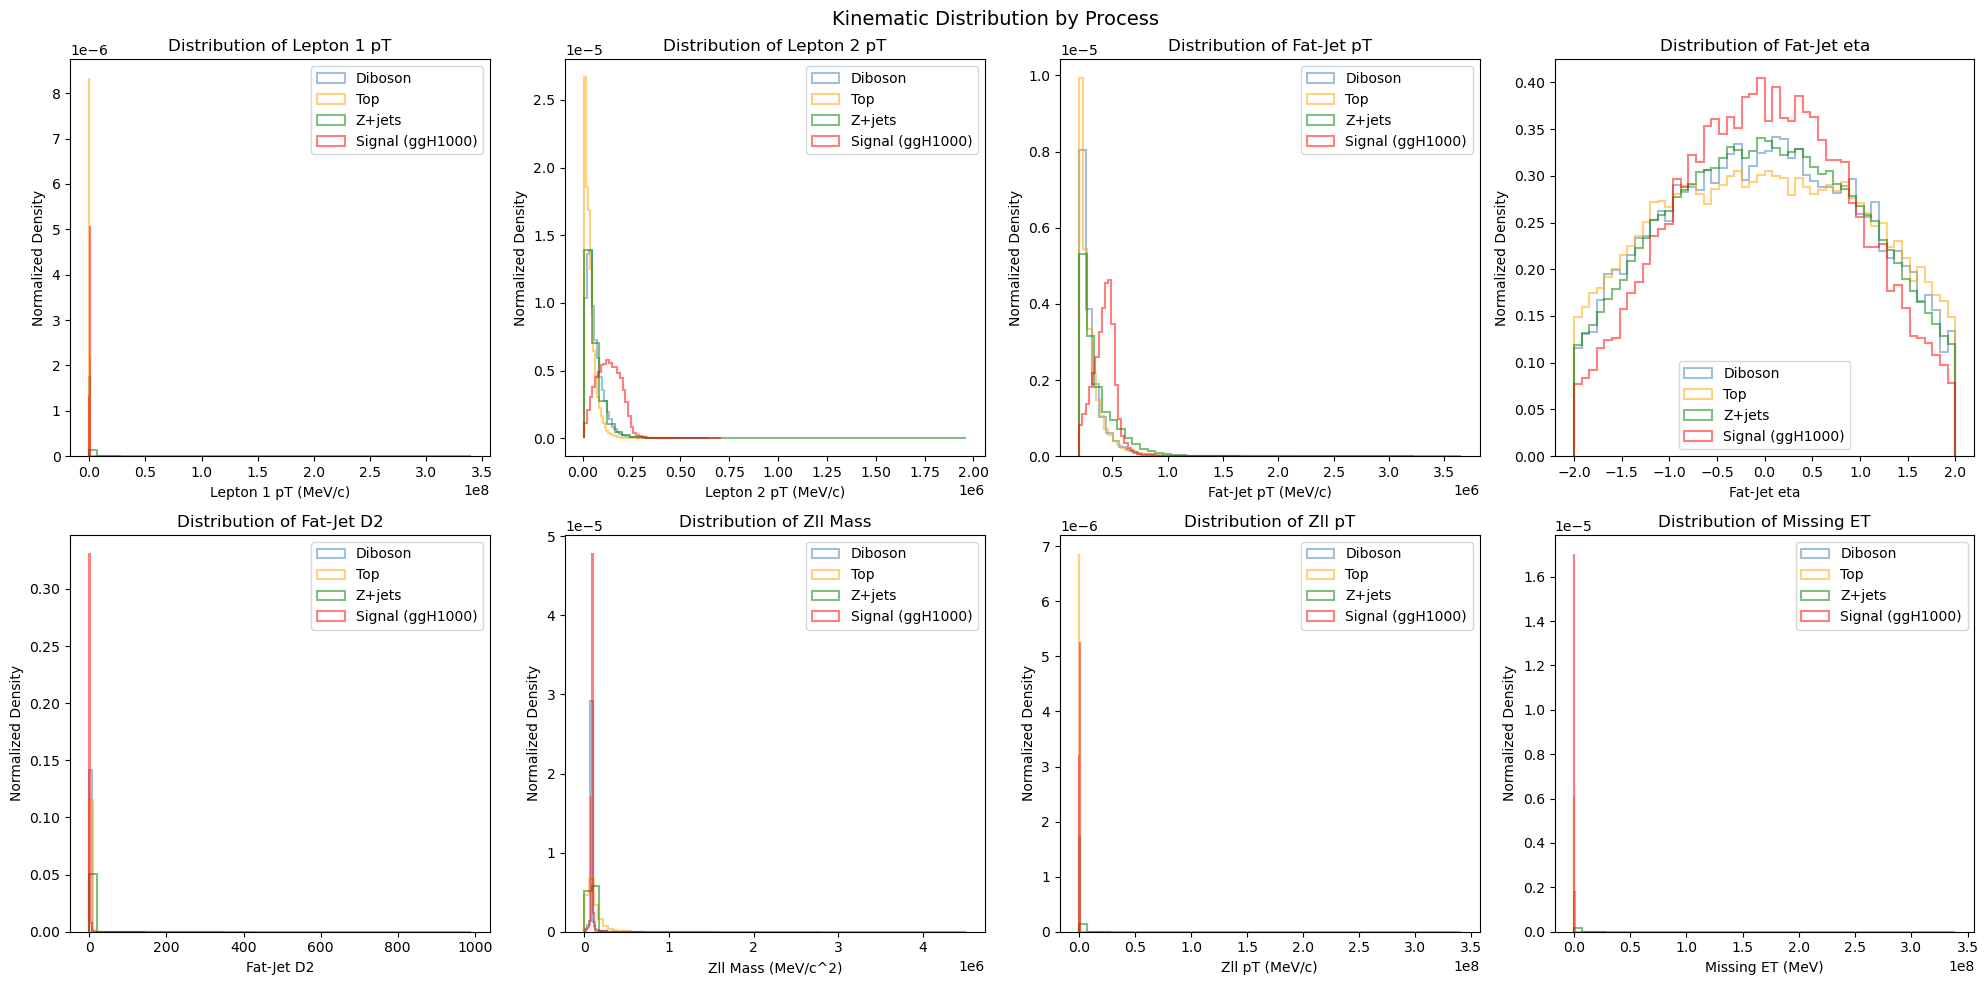

In [57]:
# Plotting: variables, labels, and units
plot_vars = {
    'lep1_pt': ('Lepton 1 pT', 'MeV/c'),
    'lep2_pt': ('Lepton 2 pT', 'MeV/c'),
    'fatjet_pt': ('Fat-Jet pT', 'MeV/c'),
    'fatjet_eta': ('Fat-Jet eta', ''),
    'fatjet_D2': ('Fat-Jet D2', ''),
    'Zll_mass': ('Zll Mass', 'MeV/c^2'),
    'Zll_pt': ('Zll pT', 'MeV/c'),
    'MET': ('Missing ET', 'MeV')
    # No reco_zv_mass since it is not used for training
}

# List of processes for plotting
processes = [
    (diboson, 'Diboson', 'steelblue'),
    (top, 'Top', 'orange'),
    (zjets, 'Z+jets', 'green'),
    (signal, 'Signal (ggH1000)', 'red')]

# Plotting

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (col, (label, unit)) in zip(axes, plot_vars.items()):
    for df, name, color in processes:
        vals = df[col].dropna()
        weights = df.loc[vals.index, 'Weight']

        # Normalize to unit area
        ax.hist(vals, bins = 50, weights = weights, histtype = 'step', linewidth = 1.5,  alpha = 0.5, label = name, color = color, density=True)
    ax.set_xlabel(f"{label} ({unit})" if unit else label)
    ax.set_ylabel("Normalized Density")
    ax.set_title(f"Distribution of {label}")
    ax.legend()

plt.suptitle("Kinematic Distribution by Process", fontsize = 14)
plt.tight_layout()
plt.show()

The distributions above have large tails present in most of the variables, replotting the axis with limits around the peaks will enable better visualization on where to make the cuts.

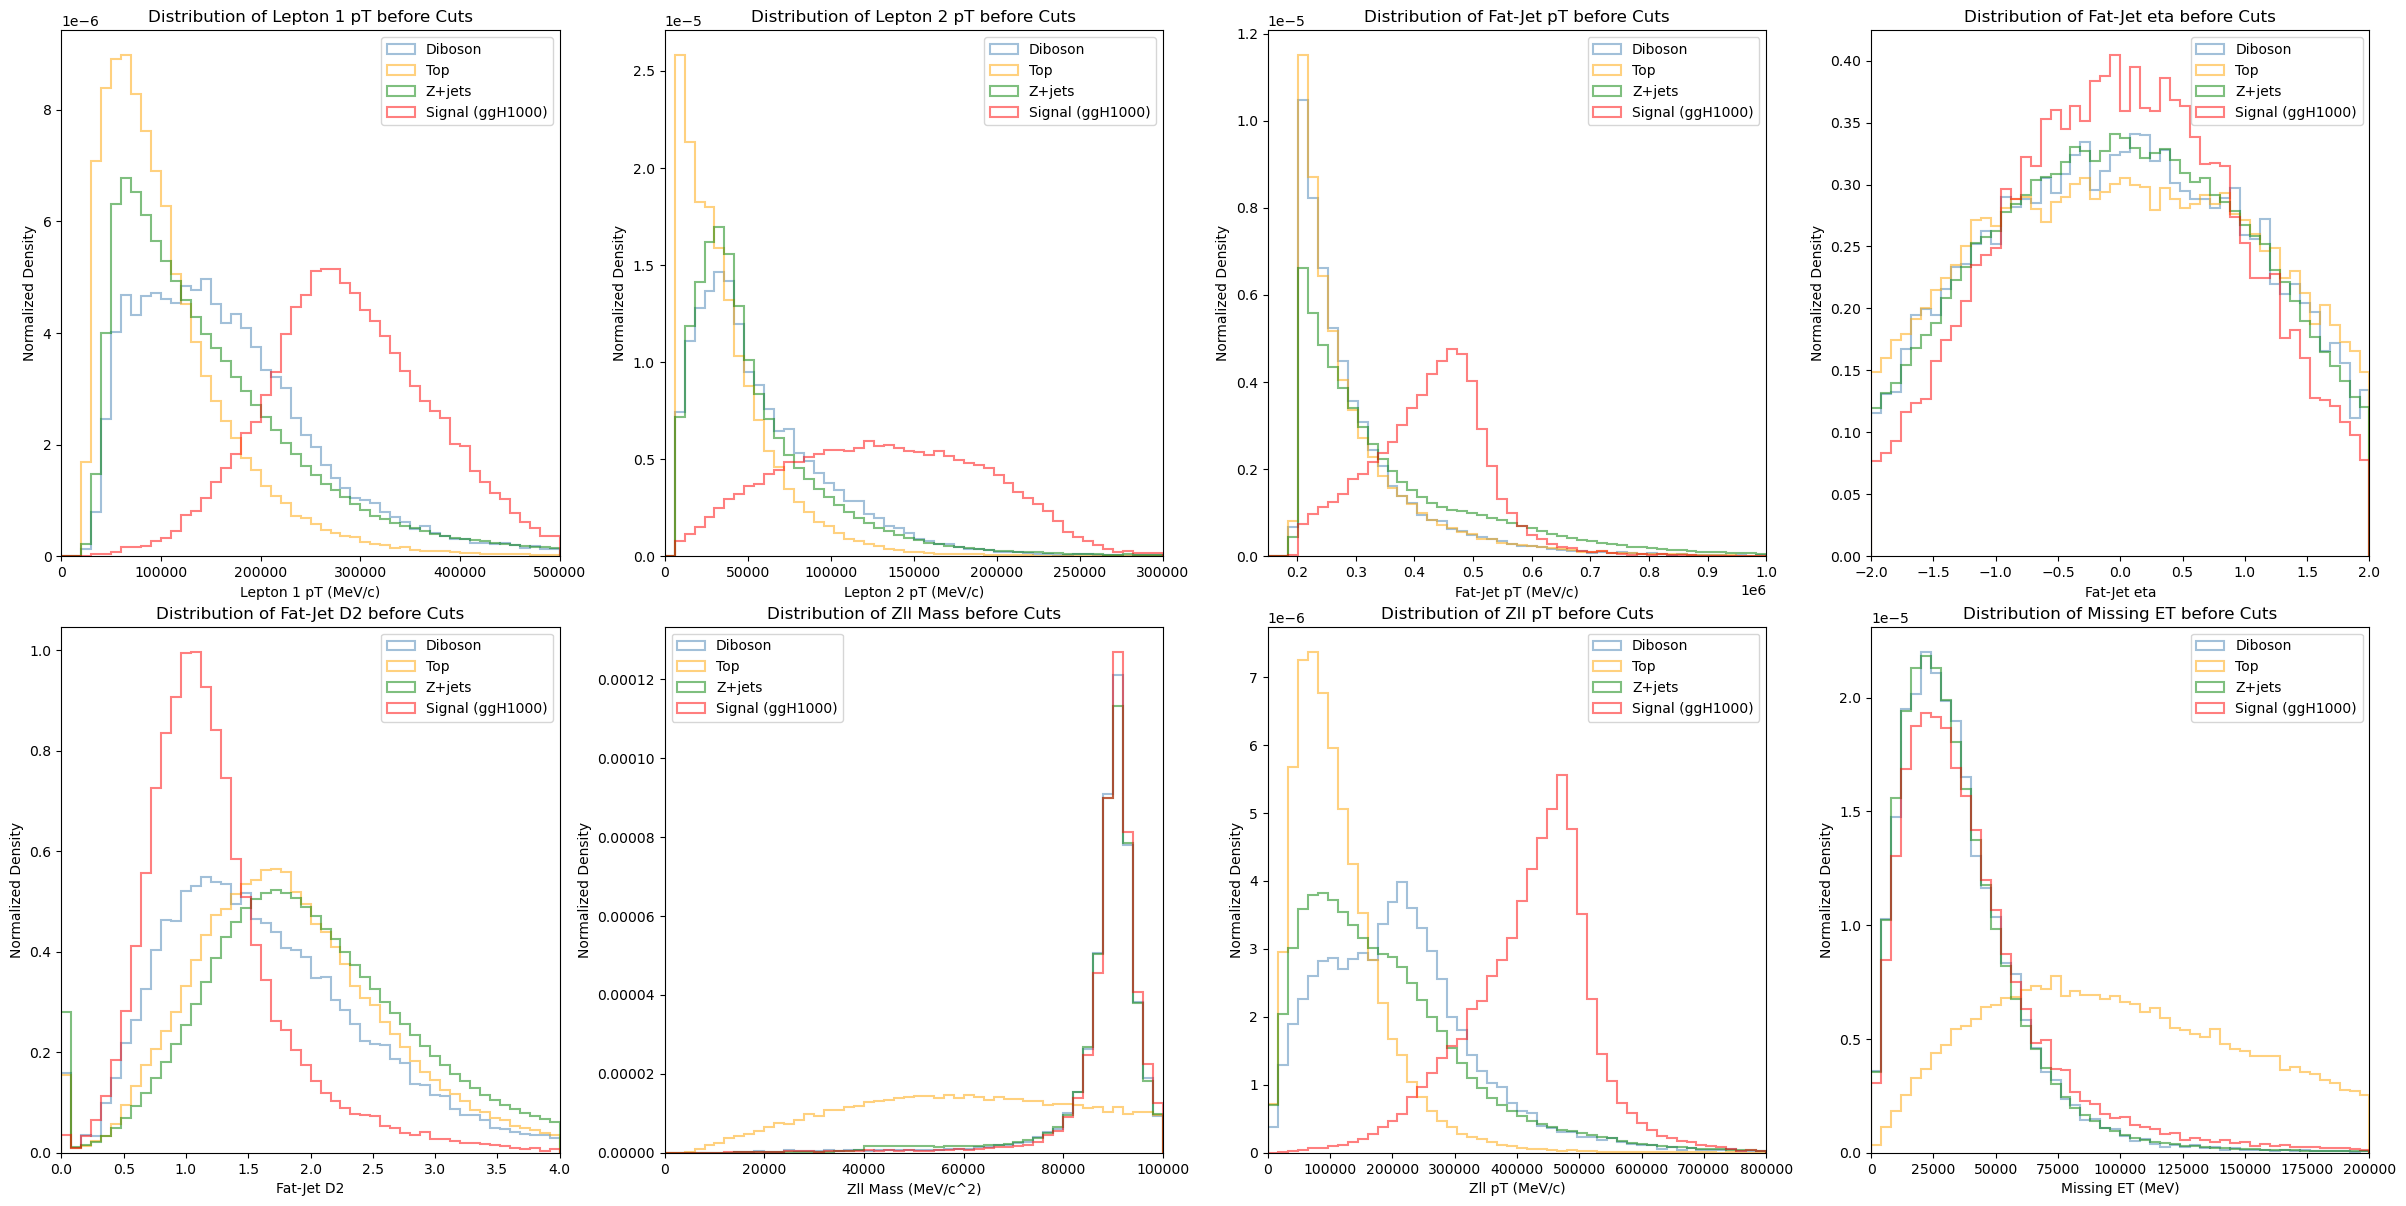

In [58]:
# Choose limits based on the distributions for better visualization before doing the cuts
plot_vars_lim = {
    'lep1_pt': ('Lepton 1 pT', 'MeV/c', (0, 500000)),
    'lep2_pt': ('Lepton 2 pT', 'MeV/c', (0, 300000)),
    'fatjet_pt': ('Fat-Jet pT', 'MeV/c', (150000, 1000000)),
    'fatjet_eta': ('Fat-Jet eta', '', (-2, 2)),
    'fatjet_D2': ('Fat-Jet D2', '', (0, 4)),
    'Zll_mass': ('Zll Mass', 'MeV/c^2', (0, 100000)),
    'Zll_pt': ('Zll pT', 'MeV/c', (0, 800000)),
    'MET': ('Missing ET', 'MeV', (0, 200000))
    # No reco_zv_mass since it is not used for training
}

# Plotting after cuts
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for ax, (col, (label, unit, xlim)) in zip(axes, plot_vars_lim.items()):
    for df, name, color in processes:
        vals = df[col].dropna()
        weights = df.loc[vals.index, 'Weight']
        # Normalize to unit area
        ax.hist(vals, bins=50, weights=weights, histtype='step',range = xlim, linewidth=1.5, alpha=0.5, label=name, color=color, density=True)
    ax.set_xlim(xlim)
    ax.set_xlabel(f"{label} ({unit})" if unit else label)
    ax.set_ylabel("Normalized Density")
    ax.set_title(f"Distribution of {label} before Cuts")
    plt.tight_layout(pad = 0.5)
    ax.legend()

# Cuts

Rectangular cuts are applied to the kinematic variables to enhance the signal-to-background ratio before training. The threshold were chosen based on the observed shape of the distributions.

Background entries before cuts: 6826959, after cuts: 197657
Signal entries before cuts: 50013, after cuts: 25483

 S/B before cuts: 0.0073, after cuts: 0.1289


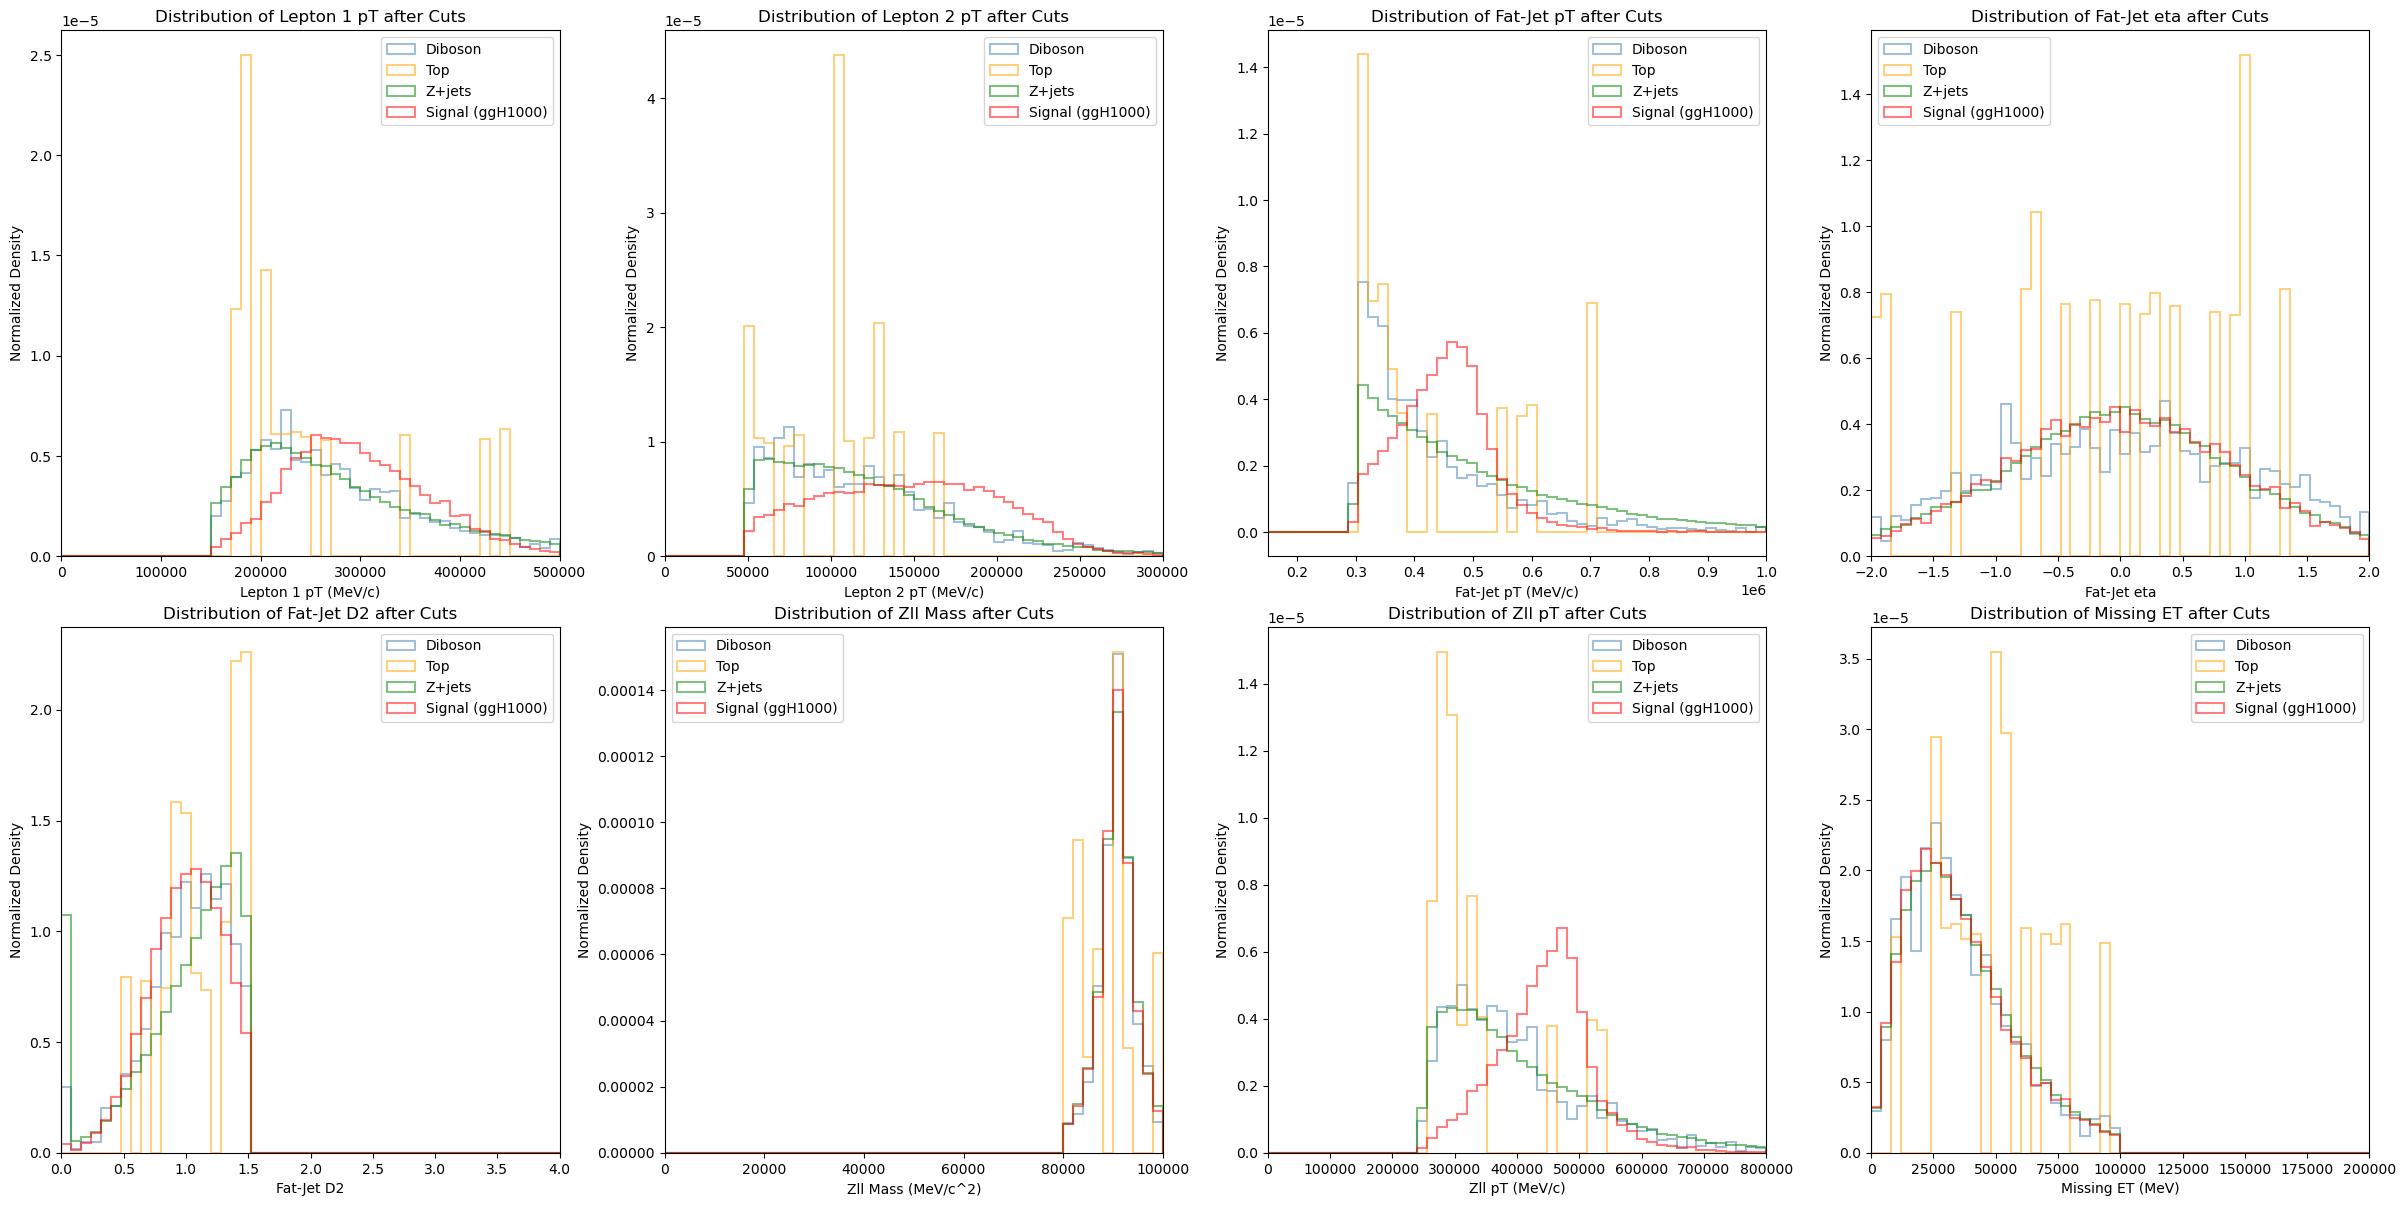

In [59]:
# Now applying cuts to try to single out the signal peaks as much as possible for training.
def apply_cuts(df):
    mask = (
        (df['lep1_pt'] > 150000) &
        (df['lep2_pt'] > 50000) &
        (df['fatjet_pt'] > 300000) & 
        # Nothing can be done for fatjet_eta since they all overlap
        (df['fatjet_D2'] < 1.5) &
        (df['Zll_mass'] > 80000) & (df['Zll_mass'] < 100000) &
        (df['Zll_pt'] > 250000) &
        (df['MET'] < 100000) # Suppresses ttbar where there is large amount of MET from neutrinos
    )
    return df[mask]

# Apply cuts to each DataFrame
diboson_cut = apply_cuts(diboson)
top_cut = apply_cuts(top)
zjets_cut = apply_cuts(zjets)
signal_cut = apply_cuts(signal)

# Combine the cut backgrounds into a single DataFrame for training
bg_cuts = pd.concat([diboson_cut, top_cut, zjets_cut], ignore_index=True)

# Print pre- and post-cut counts
print(f"Background entries before cuts: {len(backgrounds)}, after cuts: {len(bg_cuts)}")
print(f"Signal entries before cuts: {len(signal)}, after cuts: {len(signal_cut)}")
print("\n S/B before cuts: {:.4f}, after cuts: {:.4f}".format(len(signal) / len(backgrounds), len(signal_cut) / len(bg_cuts)))

process_cuts = [
    (diboson_cut, 'Diboson', 'steelblue'),
    (top_cut, 'Top', 'orange'),
    (zjets_cut, 'Z+jets', 'green'),
    (signal_cut, 'Signal (ggH1000)', 'red')
]

# Plotting after cuts with the axis limits
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for ax, (col, (label, unit, xlim)) in zip(axes, plot_vars_lim.items()):
    for df, name, color in process_cuts: # uses same limits as before to show the effect of the cuts
        vals = df[col].dropna()
        weights = df.loc[vals.index, 'Weight']
        # Normalize to unit area
        ax.hist(vals, bins=50, weights=weights, histtype='step', range=xlim, linewidth=1.5, alpha=0.5, label=name, color=color, density=True)
    ax.set_xlim(xlim)
    ax.set_xlabel(f"{label} ({unit})" if unit else label)
    ax.set_ylabel("Normalized Density")
    ax.set_title(f"Distribution of {label} after Cuts")
    plt.tight_layout(pad=0.5)
    ax.legend()

In [60]:
print(f"Diboson before cuts: {len(diboson):,} after cuts: {len(diboson_cut):,}  weighted: {diboson_cut['Weight'].sum():.1f}")
print(f"Top before cuts: {len(top):,} after cuts: {len(top_cut):,} weighted: {top_cut['Weight'].sum():.1f}")
print(f"Z+jets before cuts: {len(zjets):,} after cuts: {len(zjets_cut):,} weighted: {zjets_cut['Weight'].sum():.1f}")
print(f"Signal before cuts: {len(signal):,} after cuts: {len(signal_cut):,} weighted: {signal_cut['Weight'].sum():.1f}")

Diboson before cuts: 155,127 after cuts: 8,240  weighted: 2486.0
Top before cuts: 92,416 after cuts: 16 weighted: 13.0
Z+jets before cuts: 6,579,416 after cuts: 189,401 weighted: 158337.6
Signal before cuts: 50,013 after cuts: 25,483 weighted: 2142.8


The result of the cutting shows large amounts of background suppression, thus increasing the signal-to-background ratio from ~0.7% to ~13%. However, the ratios here are unweighted, as we will calculate the weighted value using the fit range later.

## Reconstructed $ZV$ Mass Spectrum

Plotting the 'reco_zv_mass' before and after the cuts shows the effects of the selections on the search observable. After the cuts, the 1 TeV peak is visually more prominent against the background distribution.

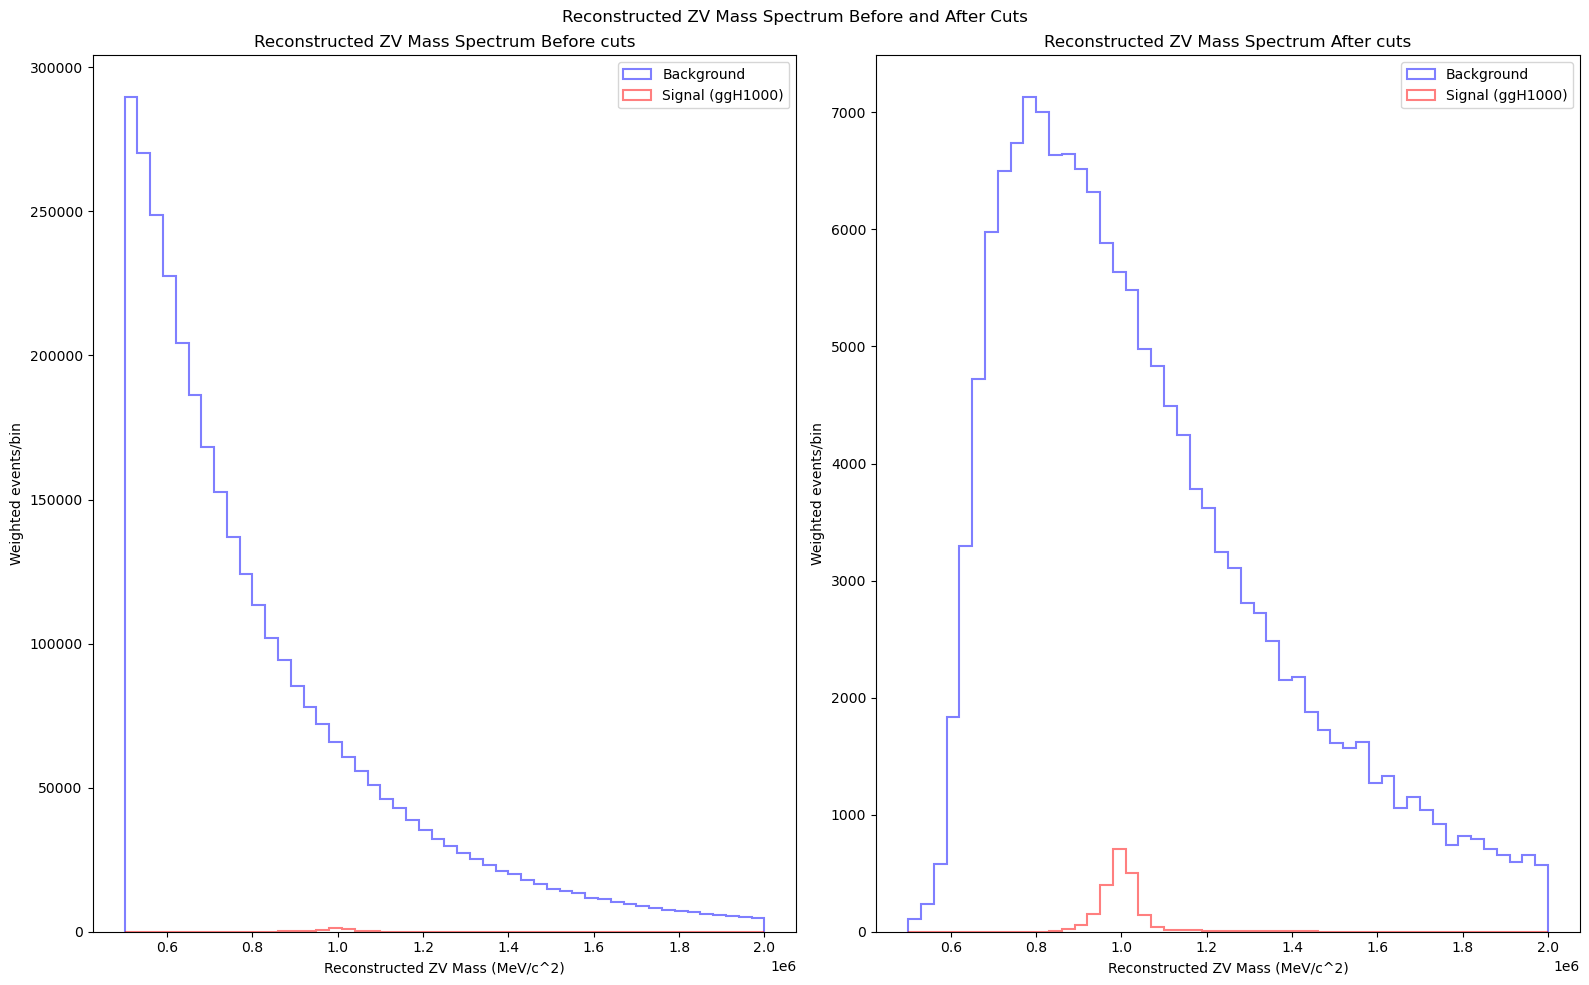

In [61]:
# Now plotting the reco_zv_mass spectrum before and after cuts to see if 1 TeV peak is visible

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
mass_range = (5e5, 2e6)

for ax, (bg, sg, title) in zip(axes, [
    (backgrounds, signal, 'Before cuts'),
    (bg_cuts, signal_cut, 'After cuts'),]):

    ax.hist(bg['reco_zv_mass'], bins=50, weights=bg['Weight'], histtype='step', linewidth=1.5, alpha=0.5, label='Background', color='blue', range = mass_range)
    ax.hist(sg['reco_zv_mass'], bins=50, weights=sg['Weight'], histtype='step', linewidth=1.5, alpha=0.5, label='Signal (ggH1000)', color='red', range = mass_range)


    ax.set_xlabel("Reconstructed ZV Mass (MeV/c^2)")
    ax.set_ylabel("Weighted events/bin")
    ax.set_title(f"Reconstructed ZV Mass Spectrum {title}")
    ax.legend()


plt.suptitle("Reconstructed ZV Mass Spectrum Before and After Cuts")
plt.tight_layout()
plt.show()

# Fitting and Hypothesis Testing

With the the post-cut dataset we perform a binned $\chi^2$ fit to the reconstructued $ZV$ mass spectrum in a window of [0.7, 1.4] TeV around the expected signal peak. Since the events are luminosity-weighted, the $\chi^2$ must be modified. In an unweighted histogram, each bin has $N_i$ events and $\sigma_i^2 = N_i$ (Poisson). However with weighted events, the bin count and its variance become:

$$N_i = \sum_{j \in \text{bin } i}^n w_j^{(i)}, \qquad \sigma_i^2 = \sum_{j \in \text{bin } i}^n (w_j^{(i)})^2$$

So the weighted $\chi^2$ is:
$$\chi^2 = \sum_i \frac{\left[N^{(i)}_{\text{observed}} - N^{(i)}_{\text{predicted}}\right]^2}{\sigma_i^2} \rightarrow \chi^2 = \sum_i \frac{\left[\displaystyle\sum_{j \in \text{bin } i}^n w_j^{(i)} - N^{(i)}_{\text{predicted}}\right]^2}{\displaystyle\sum_{j \in \text{bin } i}^n (w_j^{(i)})^2}$$

With the 'make_bins' functions computing exactly this, where for a given Dataframe, it loops over all 50 bins, accumulating 'w_sum' ($N_i$) and 'w2_sum' ($\sigma_i^2$) for each. These are then passed in each $\chi^2$ minimizer as the observed data and uncertainty.

Because this is a simulation, we keep the signal and background distinct with truth labels, fitting each in isolation first, then combining them into 'N_obs' to simulate the observed data from the hypothesis test. 

In [62]:
fit_range = (0.7e6, 1.4e6) # Fit window around signal peak
n_bins = 50

# We use n_bin + 1 edges to define the n_bin intervals
bin_edges = np.linspace(fit_range[0], fit_range[1], n_bins + 1)
# Using the center of the bin as an x value to evaluate the continuous function in the model
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mass_bins = bin_centers/ 1e6 # Convert MeV to TeV for better fitting (~ order 1)

def make_bins(df):
    w_sum = np.zeros(n_bins) # weighted event count per bin (observed)
    w2_sum = np.zeros(n_bins) # sum of weights² per bin (used as σ² in weighted chi2)

    vals = df['reco_zv_mass'].values
    weights = df['Weight'].values

    #np.digitize tells us which bin the event falls into (-1 to convert 1-index to 0-index)
    bin_indices = np.digitize(vals, bin_edges) - 1

    for i in range(n_bins):
        in_bin = (bin_indices == i)
        w_sum[i] = weights[in_bin].sum() # N_i for this bin
        w2_sum[i] = (weights[in_bin]**2).sum() # σ_i² for this bin

    return w_sum, w2_sum

N_sig, W2_sig = make_bins(signal_cut)
N_bg, W2_bg = make_bins(bg_cuts)

N_obs = N_sig + N_bg
W2_obs = W2_sig + W2_bg

print(f"Total weighted signal events in fit range: {N_sig.sum():.1f}")
print(f"Total weighted background events in fit range: {N_bg.sum():.1f}")
print(f"S/B in fit range: {N_sig.sum() / N_bg.sum():.4f}")

Total weighted signal events in fit range: 2123.9
Total weighted background events in fit range: 115042.4
S/B in fit range: 0.0185


# Fit signal-only with a Gaussian

The expected result for the signal is a narrow peak around the resonance mass, with fitting that follows:

$$f_{\text{sig}}(x; \mu, \sigma, N_s) = N_s \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

This is achieved by minimizing the weighted $\chi^2$ over $(\mu, \sigma, N_s)$ with initial guesses: $\mu = 1.0$ TeV, $\sigma = 0.05$ TeV (50 GeV), and $N_s = $ maximum bin count, giving us the peak position and width. In the following fits, we fix the signal shape ($\mu$ and $\sigma$) as they are determined from the simulation, leaving just the signal normalization ($N_s$) variable.

Signal Guassian fit: µ = 0.996 TeV, σ = 0.036 TeV, norm = 303.7


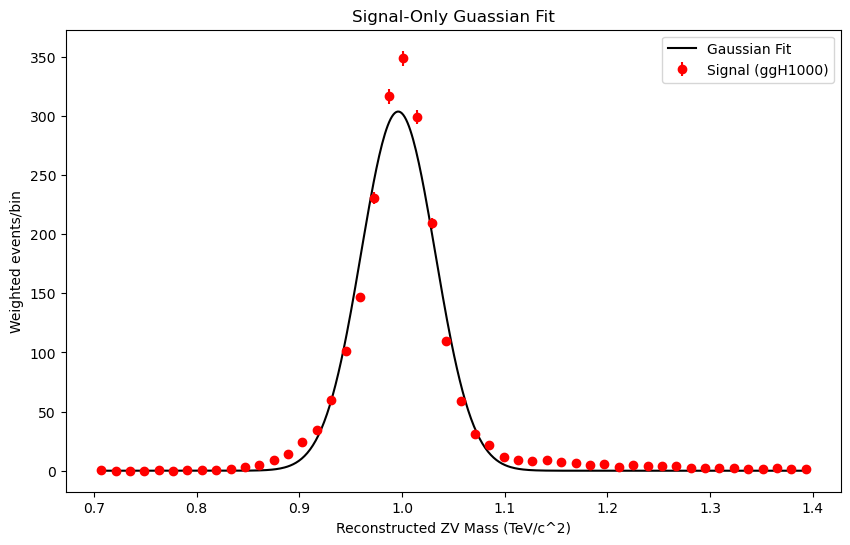

In [63]:
def gauss(x, mu, sigma, norm):
    return norm * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def chi2_sig(params):
    mu, sigma, norm = params
    # x = mass_bins
    pred = gauss(mass_bins, mu, sigma, norm)
    mask = W2_sig > 0 # Only bins with entries
    return np.sum(((N_sig[mask] - pred[mask]) ** 2) / W2_sig[mask])

# Chose guesses µ = 1 TeV, σ = 50 GeV, and norm = tallest bin
result_sig = minimize(chi2_sig, x0 = [1.0, 0.05, N_sig.max()])

mu_fit, sigma_fit, norm_fit = result_sig.x
print(f"Signal Guassian fit: µ = {mu_fit:.3f} TeV, σ = {sigma_fit:.3f} TeV, norm = {norm_fit:.1f}")

plt.figure(figsize=(10, 6))
plt.errorbar(mass_bins, N_sig, yerr=np.sqrt(W2_sig), fmt='o', label='Signal (ggH1000)', color='red')
x_fine = np.linspace(mass_bins[0], mass_bins[-1], 500) # chose finer x for smooth curve
plt.plot(x_fine, gauss(x_fine, mu_fit, sigma_fit, norm_fit), label='Gaussian Fit', color='black')
plt.xlabel("Reconstructed ZV Mass (TeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title('Signal-Only Guassian Fit')
plt.legend()
plt.show()
    

The Gaussian fit confirms the signal peak at $\sim 1$ TeV, the fitted values $\hat{\mu}$ and $\hat{\sigma}$ are now fixed for future fits.

# Fit Background-only with Polynomial

The background spectrum falls steeply and smoothly with mass, thus we model with an exponential polynomial:

$$f_{\text{bg}}(x; a, b, c) = e^{a + bx + cx^2}$$

This is a fit to the background-only histogram as to obtain good initial parameter estimates before moving onto the full combined fit.

Background fit parameters: a = 6.527, b = 4.173, c = -2.827


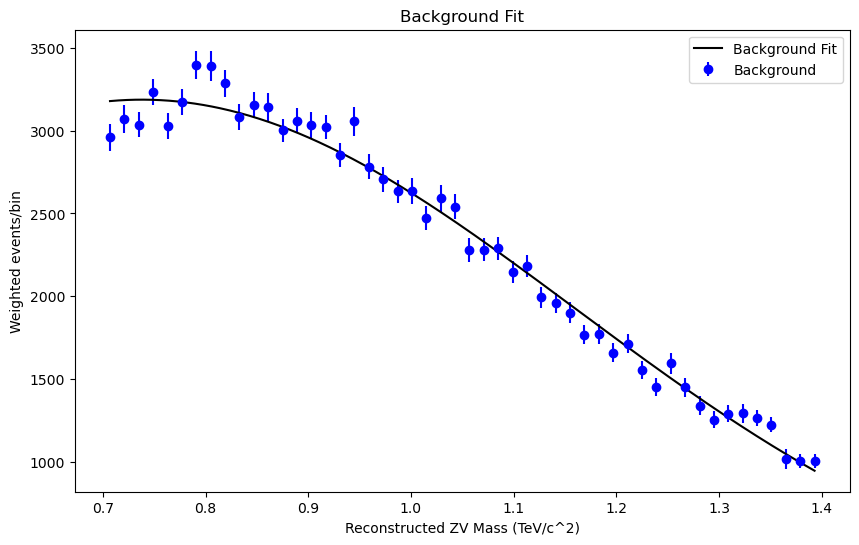

In [64]:
def bg_poly(x, a, b, c):
    # Exponential polynomial, good for steeply falling background spectra
    return np.exp(a + b * x + c * x**2)

def chi2_bg(params):
    a, b, c = params
    pred = bg_poly(mass_bins, a, b, c)
    mask = W2_bg > 0 # Only bins with entries
    return np.sum(((N_bg[mask] - pred[mask]) ** 2) / W2_bg[mask])

# Initial guess: a = 10, b = -3, c = 0
res_bg = minimize(chi2_bg, x0 = [10, -3, 0])
a_fit, b_fit, c_fit = res_bg.x # fitted background parameters
print(f"Background fit parameters: a = {res_bg.x[0]:.3f}, b = {res_bg.x[1]:.3f}, c = {res_bg.x[2]:.3f}")

plt.figure(figsize=(10, 6))
plt.errorbar(mass_bins, N_bg, yerr=np.sqrt(W2_bg), fmt='o', label='Background', color='blue')
plt.plot(x_fine, bg_poly(x_fine, a_fit, b_fit, c_fit), label='Background Fit', color='black')
plt.xlabel("Reconstructed ZV Mass (TeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title('Background Fit')
plt.legend()
plt.show()

The exponential polynomial describes the falling background spectrum well, and the fitted parameters $(a, b, c)$ are used as initial guesses in the subsequent $H_1$ fit.

# H1 Fit (Signal + Background)

The $H_1$ model contains both the Gaussian signal and background exponential polynomial fit to the combined observed spectrum $N_\text{obs} = N_\text{sig} + N_\text{bg}$:

$$f_{H_1}(x; N_s, a, b, c) = f_{\text{sig}}(x; \hat{\mu}, \hat{\sigma}, N_s) + f_{\text{bg}}(x; a, b, c)$$

The minimizer varies four parameters, signal normalization ($N_s$) and the background shape parameters $(a, b, c)$, using the previously fitted values as the initial guesses. We hope to see a good fit where $\chi^2_{H_1} / n_\text{bins} \approx 1$.

In [65]:
def model_H1(x, n_s, a, b, c):
    sig = gauss(x, mu_fit, sigma_fit, n_s)
    bg = bg_poly(x, a ,b, c)
    return sig + bg

def chi2_H1(params):
    n_s, a, b, c = params
    pred = model_H1(mass_bins, n_s, a, b, c)
    mask = W2_obs > 0 # Only bins with entries
    return np.sum(((N_obs[mask] - pred[mask]) ** 2) / W2_obs[mask])

# Initial guess: fitted values
res_H1 = minimize(chi2_H1, x0 = [norm_fit, a_fit, b_fit, c_fit])
chi2_H1_min = res_H1.fun # minimum chi2 value for H1 fit

print(f"H1 fit chi2 = {chi2_H1_min:.4f}, (signal norm = {res_H1.x[0]:.1f})")
print(f"chi2/n_bins = {chi2_H1_min / n_bins:.4f}")

H1 fit chi2 = 96.5074, (signal norm = 308.3)
chi2/n_bins = 1.9301


The reduced $\chi^2_{H_1} / n_\text{bins} = 1.93$, is of the order of the ideal value ( = 1), but doesn't fully capture every feature of the background shape using a simple exponential polynomial. The fitted signal normalization ($N_s = 308.3$) tells us how much signal the fit found, but what matters is the $\chi$ difference with the $H_0$ fit to get the significance.

# H0 Fit (Background only)

The nul hypothesis ($H_0$) uses only the background spectrum:

$$f_{H_0} (x; a, b, c) = f_{\text{bg}}(x; a, b, c)$$

Fitting $H_0$ to the combined observed spectrum forces the background polynomial to absorb the signal bump, which would result in a larger $\chi^{2, \text{min}}_{H_0}$ than $H_1$, and we'll use the difference $\Delta\chi^2 = \chi^{2, \text{min}}_{H_0} - \chi^{2, \text{min}}_{H_0}$ as the test statistic in Wilks' theorem.

In [66]:
def model_H0(x, a, b, c):
    return bg_poly(x, a, b, c) # no signal component
    
def chi2_H0(params):
    a, b, c = params
    pred = model_H0(mass_bins, a, b, c) # no signal component
    mask = W2_obs > 0 # Only bins with entries
    return np.sum(((N_obs[mask] - pred[mask]) ** 2) / W2_obs[mask])

# Initial guess: fitted background parameters
res_H0 = minimize(chi2_H0, x0 = [a_fit, b_fit, c_fit])
chi2_H0_min = res_H0.fun # minimum chi2 value for H0 fit

print(f"H0 fit chi2 = {chi2_H0_min:.4f}")

H0 fit chi2 = 143.2192


The $\chi^2_{H_0} = 143.2$ is notably larger than $\chi^2_{H_1} = 96.5$, confirming that the backgrond-only model struggles to adapt to the signal bump.

# Significance (Wilks' Theorem)

Wilks' theorem states that under $H_0$, the test statistic $\Delta\chi^2 = \chi^{2, \text{min}}_{H_0} - \chi^{2, \text{min}}_{H_0}$ follows a $\chi^2$ distribution with degrees of freedom equal to the difference in the free parameters between the two models (where $H_1 = 4 \text{ with } N_s,a,b,c$ and $H_0 = 3 \text{ with }a,b,c$), therefore $\Delta k = 1$. This is used in the p-value calculation as it calculates how likely the $\chi^2_{k = 1}$ distribution would produce such a $\Delta\chi^2$ value:

$$ p = P(\chi^2_{k = 1} > \Delta\chi^2)$$

and the significance in Guassian standard deviation is approximated as:

$$Z \approx \sqrt{\Delta\chi^2}$$

Where the conventional particle physics discovery threshold is $Z \geq 5 \sigma$, corresponding to a $95\%$ confidence.

Delta chi2 = 46.7118, p-value = 8.2234e-12, significance = 6.83 sigma


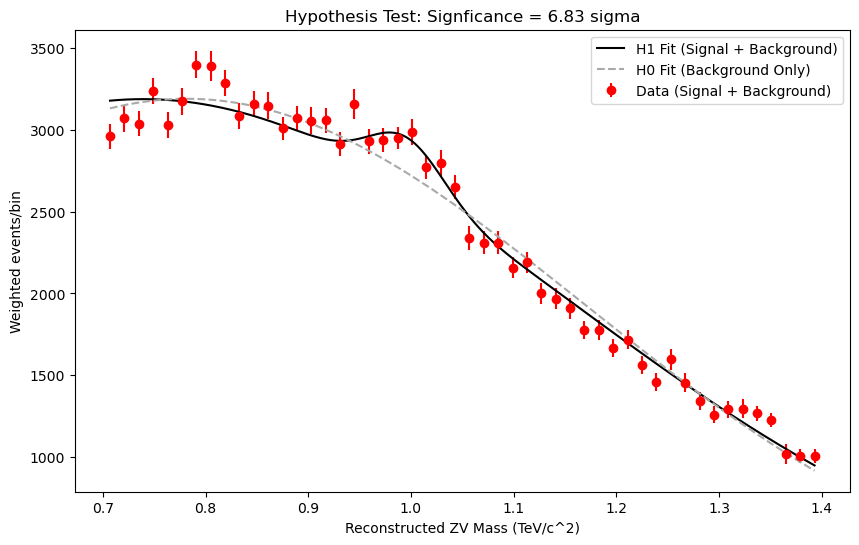

In [67]:
delta_chi2 = chi2_H0_min - chi2_H1_min # should be positive if signal improves fit

n_dof = 1 # difference in number of parameters between H1 and H0 (signal norm)
p_value = chi2_dist.sf(delta_chi2, n_dof) # survival function gives p-value for observed delta_chi2

signficance = np.sqrt(delta_chi2) # Convert p-value to significance (Z-score)

print(f"Delta chi2 = {delta_chi2:.4f}, p-value = {p_value:.4e}, significance = {signficance:.2f} sigma")

plt.figure(figsize=(10, 6))
plt.errorbar(mass_bins, N_obs, yerr=np.sqrt(W2_obs), fmt='o', label='Data (Signal + Background)', color='r')
x_fine = np.linspace(mass_bins[0], mass_bins[-1], 500)
# *res_H.x unpacks the fitted values to plot
plt.plot(x_fine, model_H1(x_fine, *res_H1.x), label='H1 Fit (Signal + Background)', color='black')
plt.plot(x_fine, model_H0(x_fine, *res_H0.x), label='H0 Fit (Background Only)', color='darkgray', linestyle='--')
plt.xlabel("Reconstructed ZV Mass (TeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title(f"Hypothesis Test: Signficance = {signficance:.2f} sigma")
plt.legend()
plt.show()

The significance of $6.83 \sigma$ well exceeds the $5 \sigma$ threshold for discovery. The plot shows the $H_1$ fit tracking the signal bump around 1.0 TeV while the $H_0$ fit undershoots it, confirming that the background-only model cannot account for the bump.

## Neural Network Classifier

The rectangular cuts are a simple approach but not optimal as they treat each variable independently without any consideration for correlations between them. A neural network classifier can learn the complex multi-dimensional relations to better suppress the background while retaining the signal. Therefore, we train a binary classifier using PyTorch on the same 8 kinematic features with the 'isSignal' as the target label. 

Since the post-cut background has a size $\sim 17\times$ that of the signal, we balance the datasets with a 50/50 training set of background and signal data. Otherwise there would be a bias in the network which would heavily lean towards predicting background.

In [68]:
features = ['lep1_pt', 'lep2_pt', 'fatjet_pt', 'fatjet_eta', 'fatjet_D2', 'Zll_mass', 'Zll_pt', 'MET']

# 50/50 split

n_sig = len(signal_cut)
bg_sample = bg_cuts.sample(n=n_sig, random_state=seed) # sample background to match signal count for balanced training

# Add isSignal label
signal_cut_labeled = signal_cut.copy()
signal_cut_labeled['isSignal'] = 1

bg_sample_labeled = bg_sample.copy()
bg_sample_labeled['isSignal'] = 0

# Combine and shuffle the data
train_df = pd.concat([signal_cut_labeled, bg_sample_labeled], ignore_index=True)
train_df = shuffle(train_df, random_state=seed).reset_index(drop = True)

# Extract features and labels for training
x = train_df[features].values
y = train_df['isSignal'].values

# Print verification
print(f"Training set size: {len(train_df)}, Signal count: {y.sum()}, Background count: {len(train_df) - y.sum()}")

Training set size: 50966, Signal count: 25483, Background count: 25483


The balanced dataset is split to $80\%$ training and $20\%$ testing to provide an unbiased estimate of the classifier performance with data it didn't train on. Each feature is then standardized with 'StandardScalar' as the neural network is sensitive to the scale of the inputs (so features like 'lep1_pt' in MeV would dominate the gradient updates compared to the unitless features).

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)

# Normalize features using StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # make it a column vector
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoader for training
# Initial batchsize set to 256
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

## Neural Network Architecture and Training

The classifier uses three hidden layers spanning:

$$n_{\text{inputs}} \xrightarrow{} 128 \xrightarrow{} 128 \xrightarrow{} 64 \xrightarrow{} 1$$

Each hidden layer is followed by ReLU activation and $10\%$ Dropout to enable non-linearity and reduce over-fitting. The output layer uses Sigmoid to produce a signal probability.

The loss function chosen is the Binary Cross-Entropy as it penalizes confident wrong predictions, good for binary classification as used in the workshops.

We use early stopping if the validation loss hasn't improved in 5 consecutive epochs as to not over-fit.

In [70]:
# First model with 3 hidden layers, n_inputs -> 128 -> 128 -> 64 -> 1 output
def nn_model(n_inputs):
    return nn.Sequential(
        nn.Linear(n_inputs, 128), nn.ReLU(), nn.Dropout(0.1),
        nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.1),
        nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.1),
        nn.Linear(64, 1), nn.Sigmoid()
    )

model = nn_model(len(features))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss() # Binary Cross-Entropy Loss

n_epochs = 50
train_losses, test_losses = [], []
test_acc = []

# Break conditions
patience = 5
best_loss = float('inf') # initialize best loss to infinity so any improvement will be detected
epochs_without_improvement = 0
best_model_weights = None # to store the best model weights

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        test_outputs = model(x_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()
        test_losses.append(test_loss)
        predicted = (test_outputs >= 0.5).float()
        acc = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
        test_acc.append(acc) 

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    # Early stopping check
    if test_loss < best_loss:
        best_acc = test_loss
        epochs_without_improvement = 0
        best_model_weights = model.state_dict() # save the best model weights
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch: {epoch+1}, best test loss: {best_acc:.4f}")
        break

# Load the best model weights before evaluation
model.load_state_dict(best_model_weights)

Epoch 1/50, Train Loss: 0.5493, Test Loss: 0.5035, Test Accuracy: 0.7578
Epoch 5/50, Train Loss: 0.4957, Test Loss: 0.4902, Test Accuracy: 0.7613
Epoch 10/50, Train Loss: 0.4906, Test Loss: 0.4875, Test Accuracy: 0.7618
Epoch 15/50, Train Loss: 0.4867, Test Loss: 0.4871, Test Accuracy: 0.7641
Epoch 20/50, Train Loss: 0.4845, Test Loss: 0.4883, Test Accuracy: 0.7615
Epoch 25/50, Train Loss: 0.4827, Test Loss: 0.4887, Test Accuracy: 0.7614
Epoch 30/50, Train Loss: 0.4827, Test Loss: 0.4880, Test Accuracy: 0.7632
Epoch 35/50, Train Loss: 0.4793, Test Loss: 0.4865, Test Accuracy: 0.7618
Epoch 40/50, Train Loss: 0.4783, Test Loss: 0.4863, Test Accuracy: 0.7635
Epoch 45/50, Train Loss: 0.4774, Test Loss: 0.4888, Test Accuracy: 0.7617
Epoch 50/50, Train Loss: 0.4760, Test Loss: 0.4893, Test Accuracy: 0.7623


<All keys matched successfully>

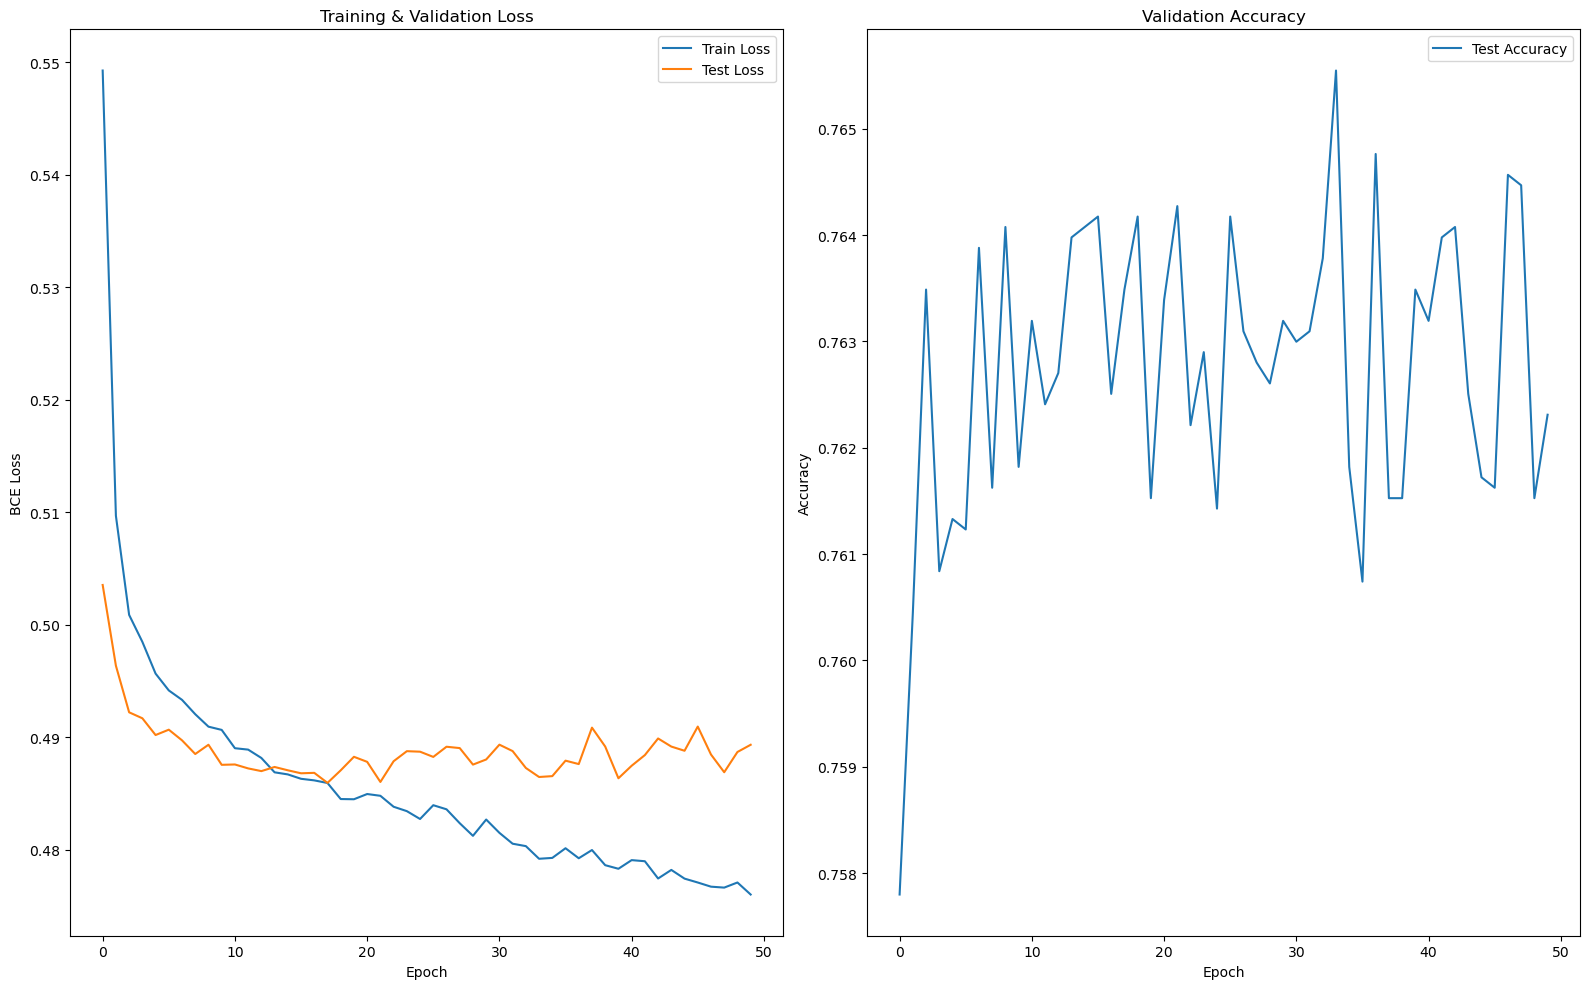

Final Validation Accuracy: 0.7623


In [71]:
plt.figure(figsize=(16, 10))

plt.subplot(1, 2 ,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f'Final Validation Accuracy: {test_acc[-1]:.4f}')

The train and validation losses decrease together and plateau at similar values, indicating that the model generalizes well without over-fitting. However, the validation accuracy of $\sim 76\%$ is notably lower than the initial accuracy (without 'reco_zv_mass') of $\sim 89\%$ achieved in the ATLAS classification workshop which used the same full uncut dataset. This is a consequence of the pre-selection cuts, as removing the mostly obvious background-like events made the surviving background kinematically similar to the signal, resulting in a harder classification problem for the neural network. The cuts are still valuable in reducing training time and ensuring the hypothesis tests, and the true test of the neural networks effectiveness lies in the improved weighted S/B and discovery significance which will be examined in next section.

# Classifier Performance - ROC Curve and Confusion Matrix

We perform two standard diagnostics:
- Confusion matrix: shows the counts of true positives, true negatives, false positives, and false negatives at the default threshold $\hat{p} > 0.5$. here the false positives are background events passing the signal cut and false negatives are signal events being rejected.
- ROC Curve: plots the true positive rate (signal efficiency) against the false positive rate (background contamination) as the classification threshold is varied from 0 to 1. The area under the curve (AUC) summarizes the overal discriminating power, with AUC = 0.5 considered as random guessing and AUC = 1 as a perfect classifier.

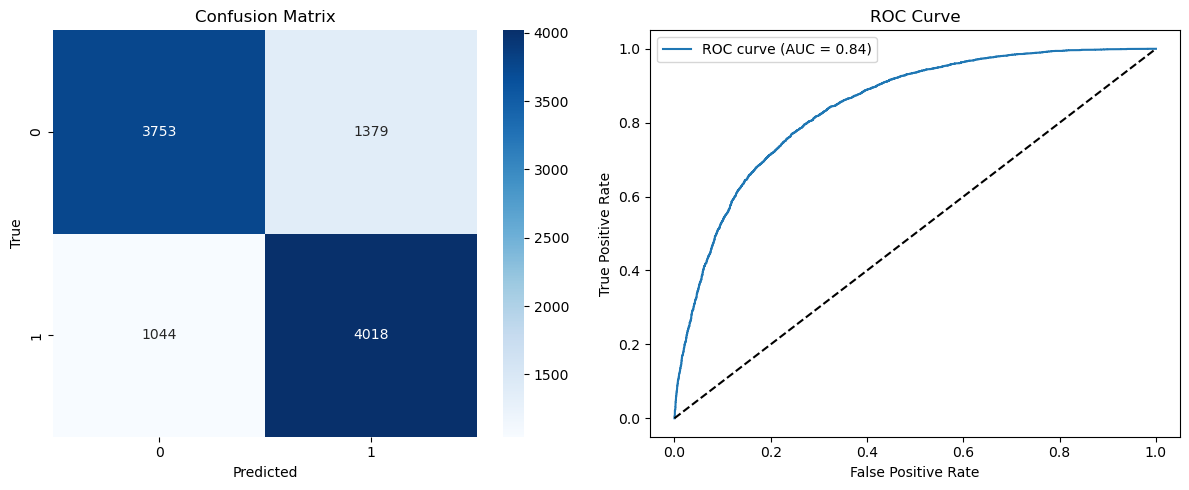

Test Accuracy: 0.7623, AUC: 0.8424


In [72]:
model.eval()
with torch.no_grad():
    probs = model(x_test_tensor).numpy().flatten() # raw probabilities
    preds = (probs >= 0.5).astype(float) # binary decision
    true = y_test_tensor.numpy().flatten() # true labels

# ROC Curve
# fpr = false positive rate 
# tpr =  true positive rate
fpr, tpr, _ = roc_curve(true, probs)
roc_auc = auc(fpr, tpr)

# Confusion Matrix
cm = confusion_matrix(true, preds)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Test Accuracy: {test_acc[-1]:.4f}, AUC: {roc_auc:.4f}")

The AUC of 0.84 indicates good discriminating, well above random guessing. From the confusion matrix, the classifier correctly identifies the majority of the signal events (4059) but misclassifies 1440 background events as signal (false positives). This relatively high false positive count is expected as noted in lecture where Z($ll$) + jets have a much larger cross-section then the signal and produces events that are geniuenly difficult to distinguish when the jets overlap with the $V \rightarrow qq'$ fat jet:

$$X \rightarrow Z(l^+l^-) + V(J) \quad \text{vs} \quad Z(ll) + \text{jets}$$

The false negative count of 1003 reflects the signal efficiency loss from the cut, events where the signal kinematics happen to resemble the background.

## Applying the Neural Network Cut to the Full Dataset

The trained classifier is applied to the entire dataset, where events with predicted signal probability $\hat{p} > 0.5$ are kept. The same scaler fitted on the training set is used on the full dataset. The comparison in weighted S/B before and after the NN cut highlights the improvement over rectangular cuts.

In [73]:
full_df = pd.concat([signal_cut, bg_cuts], ignore_index=True).copy() # use all data for final evaluation

x_full = scaler.transform(full_df[features].values) # apply same scaling as training
x_full_tensor = torch.tensor(x_full, dtype=torch.float32)

model.eval()
with torch.no_grad():
    full_probs = model(x_full_tensor).numpy().flatten() # raw probabilities for all data

full_df['nn_score'] = full_probs # add NN scores to DataFrame

nn_filtered = full_df[full_df['nn_score'] > 0.5].copy() # keep only events predicted as signal

nn_sig = nn_filtered[nn_filtered['isSignal'] == 1]
nn_bg = nn_filtered[nn_filtered['isSignal'] == 0]

print(f"After NN cut: Signal count = {len(nn_sig)}, Background count = {len(nn_bg)}, S/B = {nn_sig['Weight'].sum() / nn_bg['Weight'].sum():.4f}")
print(f"Original S/B before NN cut: {signal_cut['Weight'].sum() / bg_cuts['Weight'].sum():.4f}")

After NN cut: Signal count = 20600, Background count = 51903, S/B = 0.0417
Original S/B before NN cut: 0.0133


The neural network cut improves the weighted S/B from $1.33\%$ to $4.04\%$.

## Reconstructed $ZV$ Mass Spectrum Before and After NN Cut

Comparing the 'reco_zv_mass' spectrum before and after the NN cut shows whether the signal peak is perserved while the background is suppressed. A good classifier would sharpen the signal bump relative to the background without introducing dips/bumps in the form of bias.

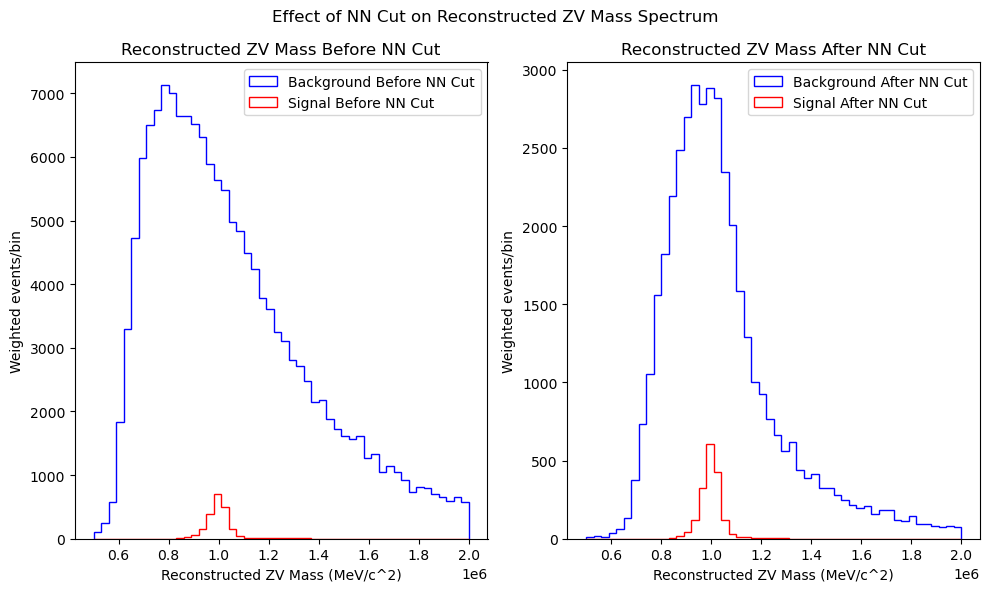

In [74]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.hist(bg_cuts['reco_zv_mass'], bins=50, weights=bg_cuts['Weight'], histtype='step', label='Background Before NN Cut', color='blue', range = mass_range)
plt.hist(signal_cut['reco_zv_mass'], bins=50, weights=signal_cut['Weight'], histtype='step', label='Signal Before NN Cut', color='red', range = mass_range)
plt.xlabel("Reconstructed ZV Mass (MeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title("Reconstructed ZV Mass Before NN Cut")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(nn_bg['reco_zv_mass'], bins=50, weights=nn_bg['Weight'], histtype='step', label='Background After NN Cut', color='blue', range = mass_range)
plt.hist(nn_sig['reco_zv_mass'], bins=50, weights=nn_sig['Weight'], histtype='step', label='Signal After NN Cut', color='red', range = mass_range)
plt.xlabel("Reconstructed ZV Mass (MeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title("Reconstructed ZV Mass After NN Cut")
plt.legend()

plt.suptitle("Effect of NN Cut on Reconstructed ZV Mass Spectrum")
plt.tight_layout()
plt.show()

After the neural network cut, the signal peak at 1 TeV is visibly more prominent while perserving the background shape. This confirms the neural network is rejecting background based on the kinematics rather than the mass variable itself, a feature we shall examine with the hypothesis tests.

# Repeat Hypothesis Test on NN-Filtered Data

We repeat the full $\chi^2$ fitting procedure and Wilks' theorem significance calculation on the NN-filtered sample. The signal and background shapes are refitted on the filtered distributions as the NN cut could reshape the mass spectrum. If the NN improved the S/B, $\Delta\chi^2$ and the significance should increase.

In [75]:
N_sig_nn, W2_sig_nn = make_bins(nn_sig)
N_bg_nn, W2_bg_nn = make_bins(nn_bg)
N_obs_nn = N_sig_nn + N_bg_nn
W2_obs_nn = W2_sig_nn + W2_bg_nn

print(f"N_sig_nn shape: {N_sig_nn.shape}")
print(f"W2_sig_nn shape: {W2_sig_nn.shape}")
print(f"n_bins: {n_bins}")
print(f"x shape: {x.shape}")

N_sig_nn shape: (50,)
W2_sig_nn shape: (50,)
n_bins: 50
x shape: (50966, 8)


In [76]:
N_sig_nn, W2_sig_nn = make_bins(nn_sig)
N_bg_nn, W2_bg_nn = make_bins(nn_bg)
N_obs_nn = N_sig_nn + N_bg_nn
W2_obs_nn = W2_sig_nn + W2_bg_nn

# Signal fit
def chi2_sig_nn(params):
    mu, sigma, norm = params
    pred = gauss(mass_bins, mu, sigma, norm)
    mask = W2_sig_nn > 0
    return np.sum(((N_sig_nn[mask] - pred[mask]) ** 2) / W2_sig_nn[mask])

res_sig_nn = minimize(chi2_sig_nn, x0 = [1.0, 0.05, N_sig_nn.max()])
mu_nn, sigma_nn, norm_nn = res_sig_nn.x

# Background fit 
def chi2_bg_nn(params):
    a, b, c = params
    pred = bg_poly(mass_bins, a, b, c)
    mask = W2_bg_nn > 0
    return np.sum(((N_bg_nn[mask] - pred[mask]) ** 2) / W2_bg_nn[mask])

res_bg_nn = minimize(chi2_bg_nn, x0 = [a_fit, b_fit, c_fit])
a_nn, b_nn, c_nn = res_bg_nn.x

# H1 fit (signal + background)
def H1_nn(params):
    n_s, a, b, c = params
    pred = model_H1(mass_bins, n_s, a, b, c)
    mask = W2_obs_nn > 0
    return np.sum(((N_obs_nn[mask] - pred[mask]) ** 2) / W2_obs_nn[mask])

res_H1_nn = minimize(H1_nn, x0 = [norm_nn, a_nn, b_nn, c_nn])
chi2_H1_nn = res_H1_nn.fun

# H0 fit (no signal)
def H0_nn(params):
    a, b, c = params
    pred = model_H0(mass_bins, a, b, c)
    mask = W2_obs_nn > 0
    return np.sum(((N_obs_nn[mask] - pred[mask]) ** 2) / W2_obs_nn[mask])

res_H0_nn = minimize(H0_nn, x0 = [a_nn, b_nn, c_nn])
chi2_H0_nn = res_H0_nn.fun

# Significance calculation
delta_chi2_nn = chi2_H0_nn - chi2_H1_nn
p_value_nn = chi2_dist.sf(delta_chi2_nn, n_dof)
significance_nn = np.sqrt(delta_chi2_nn)

print(f"Before NN cut: Delta chi2 = {delta_chi2:.4f}, p-value = {p_value:.4e}, significance = {signficance:.2f} sigma")
print(f"After NN cut: Delta chi2 = {delta_chi2_nn:.4f}, p-value = {p_value_nn:.4e}, significance = {significance_nn:.2f} sigma")
print(f'Improvement in significance: {significance_nn - signficance:.2f} sigma')


Before NN cut: Delta chi2 = 46.7118, p-value = 8.2234e-12, significance = 6.83 sigma
After NN cut: Delta chi2 = 223.5174, p-value = 1.5459e-50, significance = 14.95 sigma
Improvement in significance: 8.12 sigma


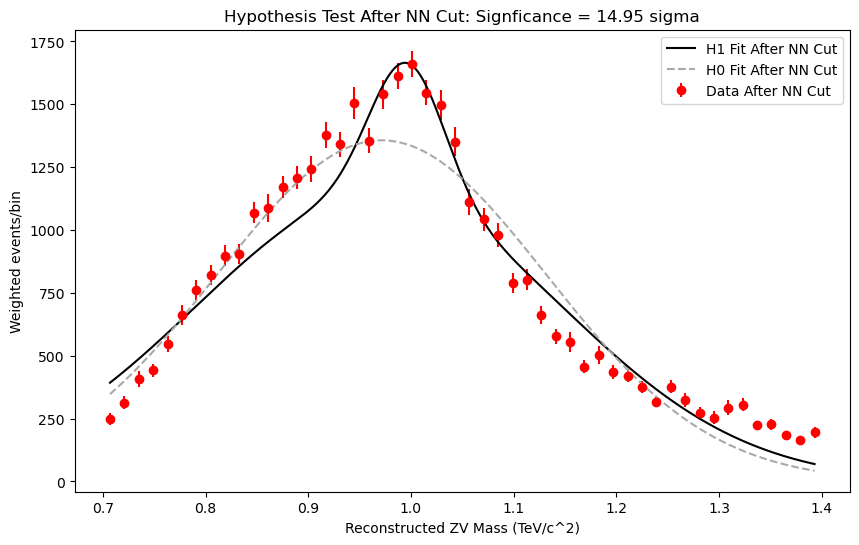

In [77]:
plt.figure(figsize=(10, 6))
plt.errorbar(mass_bins, N_obs_nn, yerr=np.sqrt(W2_obs_nn), fmt='o', label='Data After NN Cut', color='r')
plt.plot(x_fine, model_H1(x_fine, *res_H1_nn.x), label='H1 Fit After NN Cut', color='black')
plt.plot(x_fine, model_H0(x_fine, *res_H0_nn.x), label='H0 Fit After NN Cut', color='darkgray', linestyle='--')
plt.xlabel("Reconstructed ZV Mass (TeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title(f"Hypothesis Test After NN Cut: Signficance = {significance_nn:.2f} sigma")
plt.legend()
plt.show()

The NN cut more than doubles the discover significance from $6.83 \sigma$ to $14.24 \sigma$, with $\Delta\chi^2$ jumping from 46.7 to 202.6. The plot makes this more visually clear as the signal peak now dominates the spectrum and the gap between $H_1$ and $H_0$ fits around 1 TeV are much larger than before the NN cut. The p-value of $5.5 \times 10^{-46}$ is very significant, confirming that the NN cut is highly effective at enhancing the signal.

## Effects of Including 'reco_zv_mass' as a Training Feature

Following the same procedure as before but with the added 'reco_zv_mass' (the search observable that shows the signal manifests at a narrow peak of 1 TeV) as a NN input. This would be regarded as a data leakage, where the network is given access to the answer and will learn that events near 1 TeV are signal. This does artifically inflate the classifier performance, but would invalidate the hypothesis test by rejecting background events away from 1 TeV, shaping the background spectrum to mimic the signal leading to a false discovery. 

In [78]:
features_with_mass = ['lep1_pt', 'lep2_pt', 'fatjet_pt', 'fatjet_eta', 'fatjet_D2', 'Zll_mass', 'Zll_pt', 'MET', 'reco_zv_mass']

# Prepare data with reco_zv_mass included
signal_cut_labeled2 = signal_cut.copy()
signal_cut_labeled2['isSignal'] = 1
bg_sample2 = bg_cuts.sample(n=n_sig, random_state=seed)
bg_sample_labeled2 = bg_sample2.copy()
bg_sample_labeled2['isSignal'] = 0

# Train dataframes
train_df2 = pd.concat([signal_cut_labeled2, bg_sample_labeled2], ignore_index=True)
train_df2 = shuffle(train_df2, random_state=seed).reset_index(drop=True)

x2 = train_df2[features_with_mass].values
y2 = train_df2['isSignal'].values

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=seed)

scaler2 = StandardScaler()
x2_train = scaler2.fit_transform(x2_train)
x2_test = scaler2.transform(x2_test)

x2_train_tensor = torch.tensor(x2_train, dtype=torch.float32)
y2_train_tensor = torch.tensor(y2_train, dtype=torch.float32).unsqueeze(1)
x2_test_tensor = torch.tensor(x2_test, dtype=torch.float32)
y2_test_tensor = torch.tensor(y2_test, dtype=torch.float32).unsqueeze(1)

train_loader2 = DataLoader(TensorDataset(x2_train_tensor, y2_train_tensor), batch_size=256, shuffle=True)

In [79]:
model2 = nn_model(len(features_with_mass))
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
criterion2 = nn.BCELoss()

n_epochs2 = 50
train_losses2, test_losses2 = [], []
test_acc2 = []
patience2 = 5
best_loss2 = float('inf')
epochs_without_improvement2 = 0

for epoch in range(n_epochs2):
    model2.train()
    epoch_loss2 = 0
    for batch_x, batch_y in train_loader2:
        optimizer2.zero_grad()
        outputs = model2(batch_x)
        loss = criterion2(outputs, batch_y)
        loss.backward()
        optimizer2.step()
        epoch_loss2 += loss.item()
    avg_train_loss2 = epoch_loss2 / len(train_loader2)
    train_losses2.append(avg_train_loss2)

    model2.eval()
    with torch.no_grad():
        test_outputs = model2(x2_test_tensor)
        test_loss = criterion2(test_outputs, y2_test_tensor).item()
        test_losses2.append(test_loss)
        predicted = (test_outputs >= 0.5).float()
        acc = (predicted == y2_test_tensor).sum().item() / len(y2_test_tensor)
        test_acc2.append(acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs2}, Train Loss: {avg_train_loss2:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    if test_loss < best_loss2:
        best_loss2 = test_loss
        epochs_without_improvement2 = 0
    else:
        epochs_without_improvement2 += 1

    if epochs_without_improvement2 >= patience2:
        print(f"Early stopping triggered at epoch: {epoch+1}, best test loss: {best_loss2:.4f}")
        break

Epoch 1/50, Train Loss: 0.4466, Test Loss: 0.3194, Test Accuracy: 0.8707
Epoch 5/50, Train Loss: 0.3093, Test Loss: 0.2828, Test Accuracy: 0.8881
Epoch 10/50, Train Loss: 0.2997, Test Loss: 0.2822, Test Accuracy: 0.8892
Epoch 15/50, Train Loss: 0.2951, Test Loss: 0.2775, Test Accuracy: 0.8894
Epoch 20/50, Train Loss: 0.2912, Test Loss: 0.2768, Test Accuracy: 0.8902
Early stopping triggered at epoch: 21, best test loss: 0.2762


The Early stop makes sense since its using the answer, can be seen since the test accuracry is already much higher then the previous model.

S/B without reco_zv_mass: 0.0417
S/B with reco_zv_mass: 0.0869


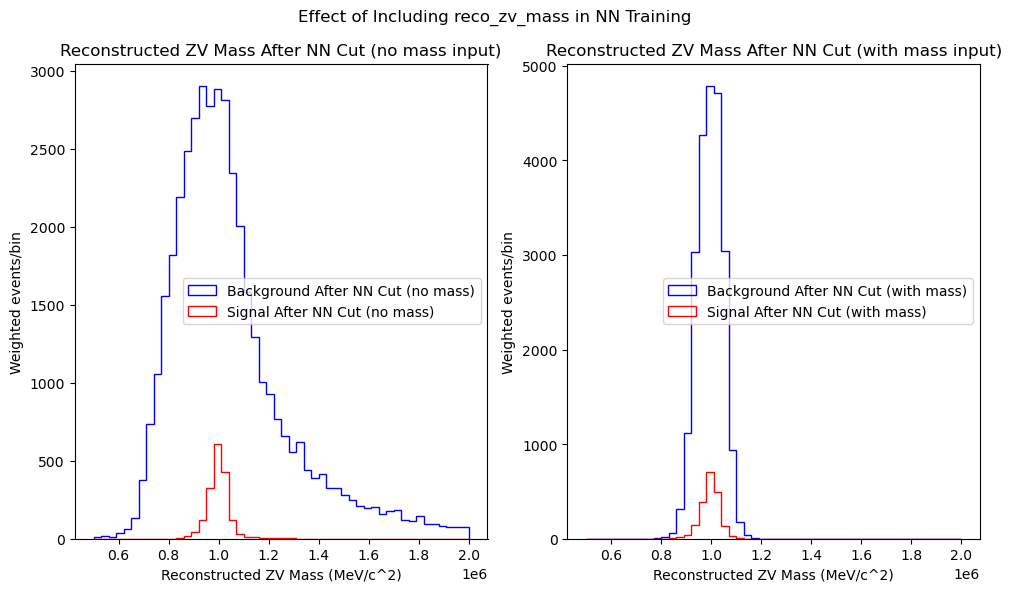

In [80]:
full_df2 = pd.concat([signal_cut, bg_cuts], ignore_index=True).copy()

x2_full = scaler2.transform(full_df2[features_with_mass].values)
x2_full_tensor = torch.tensor(x2_full, dtype=torch.float32)

model2.eval()
with torch.no_grad():
    full_probs2 = model2(x2_full_tensor).numpy().flatten()

full_df2['nn_score'] = full_probs2
nn_filtered2 = full_df2[full_df2['nn_score'] > 0.5].copy()

nn_sig2 = nn_filtered2[nn_filtered2['isSignal'] == 1]
nn_bg2 = nn_filtered2[nn_filtered2['isSignal'] == 0]

print(f"S/B without reco_zv_mass: {nn_sig['Weight'].sum() / nn_bg['Weight'].sum():.4f}")
print(f"S/B with reco_zv_mass: {nn_sig2['Weight'].sum() / nn_bg2['Weight'].sum():.4f}")

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)

plt.hist(nn_bg['reco_zv_mass'], bins=50, weights=nn_bg['Weight'], histtype='step', label='Background After NN Cut (no mass)', color='blue', range = mass_range)
plt.hist(nn_sig['reco_zv_mass'], bins=50, weights=nn_sig['Weight'], histtype='step', label='Signal After NN Cut (no mass)', color='red', range = mass_range)
plt.xlabel("Reconstructed ZV Mass (MeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title("Reconstructed ZV Mass After NN Cut (no mass input)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(nn_bg2['reco_zv_mass'], bins=50, weights=nn_bg2['Weight'], histtype='step', label='Background After NN Cut (with mass)', color='blue', range = mass_range)
plt.hist(nn_sig2['reco_zv_mass'], bins=50, weights=nn_sig2['Weight'], histtype='step', label='Signal After NN Cut (with mass)', color='red', range = mass_range)
plt.xlabel("Reconstructed ZV Mass (MeV/c^2)")
plt.ylabel("Weighted events/bin")
plt.title("Reconstructed ZV Mass After NN Cut (with mass input)")
plt.legend()

plt.suptitle("Effect of Including reco_zv_mass in NN Training")
plt.tight_layout()

With the included 'reco_zv_mass', the weighted S/B increased from $4.04\%$ to $8.91\%$, more than doubling the unbiased classifier. However, the right plot that has the included input feature highlights the issue as the background spectrum after the NN cut is much narrower around 1 TeV rather than a smooth distribution. This means that the network learned to select events near 1 TeV (the signal mass) regardless of the kinematic values, leading to a sculpted background that mimics the signal peak.